# Binary Classification of Hockey Fight Videos - Transformers

# Install kagglehub and download the Hockey Fight Videos dataset automatically into Colab’s cache.

In [1]:
# Install kagglehub
!pip install -q kagglehub

import os, glob, random, subprocess, base64
from IPython.display import HTML
import kagglehub

# Download dataset
path = kagglehub.dataset_download("yassershrief/hockey-fight-vidoes")
print("Path reported by kagglehub:", path)

100%|██████████| 164M/164M [00:11<00:00, 14.5MB/s]

Extracting files...


Path reported by kagglehub: /root/.cache/kagglehub/datasets/yassershrief/hockey-fight-vidoes/versions/1


# Part 1: Dataset acquisition and verification

# 1.1 Find the actual folder where KaggleHub saved the dataset (/root/.cache/... or /kaggle/input/...),
and confirm that the .avi files exist.

In [2]:
import os
from pathlib import Path

def find_data_root(khub_path: str):

    cands = []
    p = Path(khub_path)
    cands.append(p)
    cands.append(p / "data")

    cands.append(Path("/root/.cache/kagglehub/datasets/yassershrief/hockey-fight-vidoes/versions/1/data"))

    for c in cands:
        if c.exists() and c.is_dir():
            if list(c.glob("*.avi")):
                return str(c.resolve())
    return None

DATA_ROOT = find_data_root(path)
assert DATA_ROOT is not None, "Data root directory not found. Please make sure the download cell ran."

avi_files = sorted(glob.glob(os.path.join(DATA_ROOT, "*.avi")))
print(f"DATA_ROOT = {DATA_ROOT}")
print(f"Found {len(avi_files)} .avi files")
print("Sample:", [os.path.basename(x) for x in avi_files[:5]])

DATA_ROOT = /root/.cache/kagglehub/datasets/yassershrief/hockey-fight-vidoes/versions/1/data
Found 1000 .avi files
Sample: ['fi100_xvid.avi', 'fi101_xvid.avi', 'fi102_xvid.avi', 'fi103_xvid.avi', 'fi104_xvid.avi']


# 1.2 List the first few video filenames and confirm the dataset size (should be **1000**)

In [3]:
# Display number of files and the first few names
print(len(avi_files), [os.path.basename(x) for x in avi_files[:10]])

1000 ['fi100_xvid.avi', 'fi101_xvid.avi', 'fi102_xvid.avi', 'fi103_xvid.avi', 'fi104_xvid.avi', 'fi105_xvid.avi', 'fi106_xvid.avi', 'fi107_xvid.avi', 'fi108_xvid.avi', 'fi109_xvid.avi']


# Part 2: Quick visual checks

# 2.1 Example of fighting video. Convert it to MP4 for browser playback, since .avi is less compatible in Colab.

In [4]:
# Pick one random "fi..." sample
fi_list = [v for v in avi_files if os.path.basename(v).lower().startswith("fi")]
assert len(fi_list) > 0, "No 'fi...' videos found."
fight_vid = random.choice(fi_list)
print("Previewing fighting video:", os.path.basename(fight_vid))

# Convert to MP4 for Colab preview (5 seconds)
out = "/content/fight_preview.mp4"
subprocess.run(
    ["ffmpeg","-y","-i",fight_vid,"-t","5","-vf","scale=480:-2","-an",out],
    check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
mp4_b64 = base64.b64encode(open(out,'rb').read()).decode()
HTML(f"""<video width=480 controls><source src="data:video/mp4;base64,{mp4_b64}" type="video/mp4"></video>""")

Previewing fighting video: fi255_xvid.avi


# 2.2 Example of non-fighting video

In [5]:
no_list = [v for v in avi_files if os.path.basename(v).lower().startswith("no")]
assert len(no_list) > 0, "No 'no...' videos found."
no_vid = random.choice(no_list)
print("Previewing non-fighting video:", os.path.basename(no_vid))

out = "/content/nonfight_preview.mp4"
subprocess.run(
    ["ffmpeg","-y","-i",no_vid,"-t","5","-vf","scale=480:-2","-an",out],
    check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
mp4_b64 = base64.b64encode(open(out,'rb').read()).decode()
HTML(f"""<video width=480 controls><source src="data:video/mp4;base64,{mp4_b64}" type="video/mp4"></video>""")

Previewing non-fighting video: no391_xvid.avi


# 2.3 Use OpenCV to load the first frame and display it with Matplotlib (helps verify frame quality).

Text(0.5, 1.0, 'Example first frame')

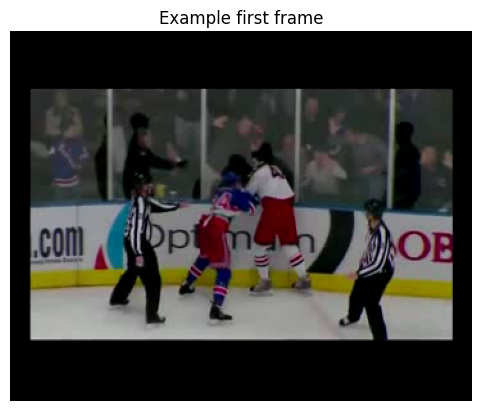

In [6]:
import cv2
import matplotlib.pyplot as plt

# Capture first frame from a random video
cap = cv2.VideoCapture(random.choice(avi_files))
ok, frame = cap.read()
cap.release()
assert ok, "Failed to read a frame."

# Convert BGR -> RGB for correct display
frame_rgb = frame[:, :, ::-1]
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Example first frame")

# 2.4 Set global constants, fix seeds for reproducibility, and select CUDA if available.

In [7]:
# Core imports
import os, glob, math, random, time
import numpy as np

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Torch / device
import torch
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


# Part 3: Split files (train/val/test) + Video pipeline + Lightwieght image subset for rapid testing

# 3.1 Make fixed splits (80/10/10) using filename prefix as label: fi*.avi → fight (label=1), no*.avi → non-fight (label=0).

In [8]:
from sklearn.model_selection import train_test_split
from pathlib import Path

# Collect all AVI files from DATA_ROOT
all_files = sorted(glob.glob(os.path.join(DATA_ROOT, "*.avi")))
assert len(all_files) > 0, "No .avi files found in DATA_ROOT."

def file_label(path):
    bn = os.path.basename(path).lower()
    if bn.startswith("fi"): return 1
    if bn.startswith("no"): return 0
    raise ValueError(f"Unknown file prefix: {bn}")

y = [file_label(p) for p in all_files]

# 80/20 split, then split the 20 into val/test (10/10 overall)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    all_files, y, test_size=0.2, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED
)

SPLIT_DIR = "/content/splits"
Path(SPLIT_DIR).mkdir(parents=True, exist_ok=True)
def dump(lst, name):
    with open(os.path.join(SPLIT_DIR, name), "w") as f: f.write("\n".join(lst))

dump(X_train, "train.txt")
dump(X_val,   "val.txt")
dump(X_test,  "test.txt")

print("Split sizes -> train:", len(X_train), "val:", len(X_val), "test:", len(X_test))
print("Saved to:", SPLIT_DIR)

Split sizes -> train: 800 val: 100 test: 100
Saved to: /content/splits


# 3.2 Switch between full dataset and small dataset

In [9]:
# --- Small-vs-Full switch ---
SPLIT_SUFFIX = "_small"   # use "" for full dataset; "_small" for 100-video lightweight run

# Target total for the lightweight set (50 fight + 50 non-fight)
SMALL_TOTAL_PER_CLASS = 50       # overall across train+val+test
# Recommended split of the 100 videos:
SMALL_TRAIN_PER_CLASS = 40       # 40 fight + 40 non-fight
SMALL_VAL_PER_CLASS   = 5        # 5  + 5
SMALL_TEST_PER_CLASS  = 5        # 5  + 5

# 3.3 Build and split small dataset

In [10]:
# --- Build lightweight splits (robust) ---
import os, random
from collections import Counter

# Config (keeps your existing globals if already set)
SPLIT_SUFFIX = "_small" if "SPLIT_SUFFIX" not in globals() else SPLIT_SUFFIX
SMALL_TRAIN_PER_CLASS = 40 if "SMALL_TRAIN_PER_CLASS" not in globals() else SMALL_TRAIN_PER_CLASS
SMALL_VAL_PER_CLASS   = 5  if "SMALL_VAL_PER_CLASS"   not in globals() else SMALL_VAL_PER_CLASS
SMALL_TEST_PER_CLASS  = 5  if "SMALL_TEST_PER_CLASS"  not in globals() else SMALL_TEST_PER_CLASS

random.seed(42)

def _is_fight(path: str) -> bool:
    """Label by filename prefix (fi*/no*)."""
    return os.path.basename(path).lower().startswith("fi")

def _split_by_label(paths):
    fi = [p for p in paths if _is_fight(p)]
    no = [p for p in paths if not _is_fight(p)]
    return fi, no

def _read_list(name):
    p = os.path.join(SPLIT_DIR, name)
    assert os.path.exists(p), f"Missing split file: {p}"
    with open(p) as f:
        return [ln.strip() for ln in f if ln.strip()]

def _write_list(paths, name):
    out = os.path.join(SPLIT_DIR, name)
    with open(out, "w") as f:
        f.write("\n".join(paths))
    return out

def _sample_per_split(full_list, n_per_class):
    """Sample n_per_class per class; fallback to min available with a warning."""
    fi, no = _split_by_label(full_list)
    need = n_per_class
    have_fi, have_no = len(fi), len(no)
    if have_fi < need or have_no < need:
        need = min(have_fi, have_no)
        print(f"Not enough videos in this split; sampling {need} per class instead of {n_per_class}.")
    pick = random.sample(fi, need) + random.sample(no, need)
    random.shuffle(pick)
    return pick

# 1) Read full splits (already made in Part 3)
train_full = _read_list("train.txt")
val_full   = _read_list("val.txt")
test_full  = _read_list("test.txt")

# 2) Sample small splits per split (keeps protocol & prevents leakage)
train_small = _sample_per_split(train_full, SMALL_TRAIN_PER_CLASS)
val_small   = _sample_per_split(val_full,   SMALL_VAL_PER_CLASS)
test_small  = _sample_per_split(test_full,  SMALL_TEST_PER_CLASS)

# 3) Write small split files
paths = [
    _write_list(train_small, "train_small.txt"),
    _write_list(val_small,   "val_small.txt"),
    _write_list(test_small,  "test_small.txt"),
]

print("Small split files created:")
for p in paths:
    print("  -", p)

# 4) Verify counts
def _count_labels(list_name):
    lst = _read_list(list_name)
    c = Counter(_is_fight(p) for p in lst)   # True=fight, False=non-fight
    fi, no = c.get(True, 0), c.get(False, 0)
    return fi, no, len(lst)

print("\nSummary of small dataset:")
for nm in ["train_small.txt", "val_small.txt", "test_small.txt"]:
    fi, no, tot = _count_labels(nm)
    print(f"{nm:<18} -> fight: {fi:>2} | non-fight: {no:>2} | total: {tot}")

total = sum(_count_labels(nm)[2] for nm in ["train_small.txt","val_small.txt","test_small.txt"])
print(f"\nTotal expected ≈ 100 videos (50 fight + 50 non-fight across splits) | actual: {total}")

# 5) (Safety) Ensure no file appears twice across small splits
def _set(nm): return set(_read_list(nm))
overlap_tv = _set("train_small.txt") & _set("val_small.txt")
overlap_tt = _set("train_small.txt") & _set("test_small.txt")
overlap_vt = _set("val_small.txt")   & _set("test_small.txt")
assert not overlap_tv and not overlap_tt and not overlap_vt, "Overlap detected across small splits!"

Small split files created:
  - /content/splits/train_small.txt
  - /content/splits/val_small.txt
  - /content/splits/test_small.txt

Summary of small dataset:
train_small.txt    -> fight: 40 | non-fight: 40 | total: 80
val_small.txt      -> fight:  5 | non-fight:  5 | total: 10
test_small.txt     -> fight:  5 | non-fight:  5 | total: 10

Total expected ≈ 100 videos (50 fight + 50 non-fight across splits) | actual: 100


# Part 4: RBG baseline: Frame-ViT + Temporal Transformer

# 4.1 RBG dataset and loader

In [11]:
import cv2
from PIL import Image
import torchvision
from torch.utils.data import Dataset, DataLoader

class VideoDataset(Dataset):
    """
    Loads a video file, uniformly samples T frames,
    applies transforms, returns a tensor [T, 3, H, W] and label.
    """
    def __init__(self, list_file, T=16, size=224, train=True):
        with open(list_file) as f:
            self.paths = [ln.strip() for ln in f if ln.strip()]
        self.T = T
        self.size = size
        self.train = train

        # ImageNet normalization
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]

        self.tf_train = torchvision.transforms.Compose([
            torchvision.transforms.Resize(256),
            torchvision.transforms.RandomCrop(size),
            torchvision.transforms.RandomHorizontalFlip(),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(mean, std),
        ])
        self.tf_eval = torchvision.transforms.Compose([
            torchvision.transforms.Resize(256),
            torchvision.transforms.CenterCrop(size),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(mean, std),
        ])

    def __len__(self): return len(self.paths)

    def _label(self, path):
        bn = os.path.basename(path).lower()
        return 1 if bn.startswith("fi") else 0

    def _sample_indices(self, n_frames):
        # Uniformly sample T indices in [0, n_frames-1]
        if n_frames <= 0: return np.zeros(self.T, dtype=int)
        return np.linspace(0, max(0, n_frames - 1), self.T).astype(int)

    def __getitem__(self, idx):
        path = self.paths[idx]
        y = self._label(path)

        # Read video metadata
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        inds = self._sample_indices(total)

        # Extract frames and transform
        imgs = []
        tf = self.tf_train if self.train else self.tf_eval
        for i in inds:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
            ok, frame = cap.read()
            if not ok:
                # Fallback: black frame in case of read error
                frame = np.zeros((256,256,3), dtype=np.uint8)
            # BGR -> RGB, to PIL, then transforms
            img = Image.fromarray(frame[:, :, ::-1])
            imgs.append(tf(img))
        cap.release()

        x = torch.stack(imgs, dim=0)  # [T, 3, H, W]
        return x, torch.tensor(y).long()

# Instantiate loaders (tune batch size for your GPU)
T = 16
BATCH = 4 if DEVICE == "cuda" else 2
train_ds = VideoDataset(os.path.join(SPLIT_DIR, "train.txt"), T=T, train=True)
val_ds   = VideoDataset(os.path.join(SPLIT_DIR, "val.txt"),   T=T, train=False)
test_ds  = VideoDataset(os.path.join(SPLIT_DIR, "test.txt"),  T=T, train=False)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds), len(test_ds)

(800, 100, 100)

# 4.2 Use a pretrained ViT-Tiny to encode each frame, then a small temporal Transformer across time.

In [12]:
# Install timm if not present (quiet)
!pip install -q timm

import timm
import torch.nn as nn
import torch.nn.functional as F

class TemporalEncoder(nn.Module):
    """Small Transformer encoder over time only."""
    def __init__(self, d_model=192, nhead=4, num_layers=3, max_T=128):
        super().__init__()
        self.pos = nn.Parameter(torch.zeros(1, max_T, d_model))
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc, num_layers=num_layers)

    def forward(self, x):  # x: [B, T, D]
        B, T, D = x.shape
        x = x + self.pos[:, :T, :]
        return self.encoder(x)  # [B, T, D]

class FrameViTTemporal(nn.Module):
    """
    Frame encoder: ViT-Tiny (pretrained, frozen).
    Temporal encoder: small Transformer over time.
    """
    def __init__(self, num_classes=2):
      super().__init__()
      # --- Load pretrained ViT backbone ---
      self.backbone = timm.create_model("vit_tiny_patch16_224", pretrained=True)
      self.backbone.reset_classifier(0)       # remove head -> use as feature extractor
      self.D = self.backbone.num_features     # 192 for ViT-Tiny

      # --- Selective fine-tuning ---
      # Freeze most layers, unfreeze the last transformer block & normalization
      for name, param in self.backbone.named_parameters():
          if any(key in name for key in ["blocks.10", "blocks.11", "norm", "head"]):
              param.requires_grad = True       # allow gradients for last few blocks
          else:
              param.requires_grad = False      # keep early layers frozen


      self.temporal = TemporalEncoder(d_model=self.D, nhead=4, num_layers=3)
      self.head = nn.Linear(self.D, num_classes)

    def forward(self, x):                   # x: [B, T, 3, H, W]
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        f = self.backbone(x)                # [B*T, D], D=192 for ViT-Tiny
        f = f.view(B, T, self.D)            # [B, T, D]
        z = self.temporal(f)                # [B, T, D]
        g = z.mean(dim=1)                   # simple temporal mean-pooling
        return self.head(g)                 # [B, num_classes]

model = FrameViTTemporal(num_classes=2).to(DEVICE)
sum(p.numel() for p in model.parameters() if p.requires_grad), model.backbone.num_features

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

(3735746, 192)

# 4.3 Train the temporal layers + head, keep best checkpoint by val macro-F1.

In [13]:
# === Lightweight Training Cell with Time Tracking ===
import time
from contextlib import nullcontext
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score

# ----- Loss, Optimizer -----
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=3e-4, weight_decay=5e-2
)

# ----- AMP setup (works for CPU or CUDA) -----
use_cuda_amp = torch.cuda.is_available() and (DEVICE == "cuda")
autocast_ctx = (lambda: torch.amp.autocast(device_type="cuda")) if use_cuda_amp else nullcontext
scaler = torch.cuda.amp.GradScaler(enabled=use_cuda_amp)

# ----- Config / speed knobs -----
EPOCHS = 2                   # use small number on CPU
MAX_TRAIN_BATCHES = 40       # None = use all batches
MAX_VAL_BATCHES   = 10
PATIENCE = 2                 # stop if no val F1 improvement for N epochs

# Save path (add suffix for _small split)
SUFFIX = (SPLIT_SUFFIX if "SPLIT_SUFFIX" in globals() else "")
BEST_PATH = f"/content/best_rgb{SUFFIX}.pt"

# Track total training time
start_total = time.time()

def run_epoch(dl, train=True, max_batches=None):
    """Run one epoch, optionally limiting number of batches."""
    model.train(train)
    losses, preds, trues = [], [], []
    b_count = 0

    for X, y in dl:
        b_count += 1
        if (max_batches is not None) and (b_count > max_batches):
            break

        X, y = X.to(DEVICE), y.to(DEVICE)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with autocast_ctx():
                logits = model(X)
                loss = criterion(logits, y)
            if use_cuda_amp:
                scaler.scale(loss).backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        else:
            with torch.no_grad():
                logits = model(X)
                loss = criterion(logits, y)

        losses.append(loss.item())
        preds.extend(logits.argmax(1).detach().cpu().tolist())
        trues.extend(y.detach().cpu().tolist())

    acc = accuracy_score(trues, preds) if trues else 0.0
    f1  = f1_score(trues, preds, average="macro") if trues else 0.0
    return (float(np.mean(losses)) if losses else 0.0), acc, f1


# ----- Training Loop -----
BEST_F1 = -1.0
no_improve = 0
epoch_times = []  # record time per epoch

print(f"Training on device: {DEVICE} | AMP: {use_cuda_amp} | Dataset: {SUFFIX or 'full'}")
print("------------------------------------------------------------")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc, tr_f1 = run_epoch(train_dl, train=True,  max_batches=MAX_TRAIN_BATCHES)
    va_loss, va_acc, va_f1 = run_epoch(val_dl,   train=False, max_batches=MAX_VAL_BATCHES)

    elapsed = time.time() - t0
    epoch_times.append(elapsed)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.3f} acc {tr_acc:.3f} f1 {tr_f1:.3f} || "
          f"val loss {va_loss:.3f} acc {va_acc:.3f} f1 {va_f1:.3f} | "
          f"time {elapsed/60:.2f} min")

    if va_f1 > BEST_F1:
        BEST_F1 = va_f1
        torch.save(model.state_dict(), BEST_PATH)
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping (no val F1 improvement for {PATIENCE} epochs).")
            break

# ----- Summary -----
total_time = time.time() - start_total
avg_epoch = np.mean(epoch_times)
print("------------------------------------------------------------")
print(f"Training finished | Best val F1: {BEST_F1:.4f}")
print(f"Avg epoch time: {avg_epoch/60:.2f} min | Total time: {total_time/60:.2f} min")
print(f"Saved best checkpoint to: {BEST_PATH}")
print("------------------------------------------------------------")

Training on device: cuda | AMP: True | Dataset: _small
------------------------------------------------------------


/tmp/ipykernel_5495/3356619832.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_cuda_amp)


Epoch 01 | train loss 0.643 acc 0.838 f1 0.835 || val loss 0.293 acc 0.975 f1 0.975 | time 0.83 min
Epoch 02 | train loss 1.091 acc 0.906 f1 0.904 || val loss 0.260 acc 0.975 f1 0.975 | time 0.55 min
------------------------------------------------------------
Training finished | Best val F1: 0.9750
Avg epoch time: 0.69 min | Total time: 1.38 min
Saved best checkpoint to: /content/best_rgb_small.pt
------------------------------------------------------------


# 4.4 Evaluate on the small test split

In [14]:
import time

# --- Evaluate best checkpoint on test set ---
t0 = time.time()
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model.eval()
_, te_acc, te_f1 = run_epoch(test_dl, train=False)
elapsed = time.time() - t0

print("------------------------------------------------------------")
print(f"[TEST: {SUFFIX or 'full'}] acc = {te_acc:.3f} | macro-F1 = {te_f1:.3f} | time = {elapsed/60:.2f} min")
print("------------------------------------------------------------")

------------------------------------------------------------
[TEST: _small] acc = 0.930 | macro-F1 = 0.930 | time = 0.38 min
------------------------------------------------------------


# 4.5 Overfitting check

In [15]:
# Overfit-check: see if RGB baseline is memorizing
import time

t0 = time.time()
# run_epoch returns (loss, acc, f1)
_, train_acc, train_f1 = run_epoch(train_dl, train=False, max_batches=3)

print(f"[Overfit check] train acc={train_acc:.3f}, f1={train_f1:.3f} | time={(time.time()-t0)/60:.2f} min")
print("If train F1 >> val/test F1, it's overfitting.")

[Overfit check] train acc=0.917, f1=0.899 | time=0.13 min
If train F1 >> val/test F1, it's overfitting.


# Part 5: The Pose Baseline model

# 5.1 Install Ultralytics for YOLOv8-pose

In [16]:
# --- Install and import Ultralytics (for YOLOv8-pose) ---
!pip install -q ultralytics

from ultralytics import YOLO
print("Ultralytics installed and YOLO ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics installed and YOLO ready.


# 5.2 Pose keypoints extraction for lightweight dataset

In [17]:
import os, cv2, numpy as np
from ultralytics import YOLO
from tqdm import tqdm
from pathlib import Path
import torch # Added torch import

# --- Pose cache directory ---
POSE_DIR = "/content/poses_npz"
os.makedirs(POSE_DIR, exist_ok=True)

# --- Pose model ---
pose_model = YOLO("yolov8n-pose.pt")  # 'n' = nano version
pose_device = "cuda" if torch.cuda.is_available() else "cpu"
pose_model.to(pose_device)

# --- Sampling utility (same as RGB baseline) ---
def sample_inds(n, T):
    if n <= 0:
        return np.zeros(T, dtype=int)
    return np.linspace(0, max(0, n - 1), T).astype(int)

# --- Extract keypoints for one video ---
def extract_video_kps(video_path, T=16):
    cap = cv2.VideoCapture(video_path)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = sample_inds(n, T)
    seq = []  # [T, 17, 3]

    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, frame = cap.read()
        if not ok:
            seq.append(np.zeros((17, 3), dtype=np.float32))
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = pose_model.predict(source=rgb, verbose=False, imgsz=640, device=pose_device)
        if len(res) == 0 or len(res[0].keypoints) == 0:
            seq.append(np.zeros((17, 3), dtype=np.float32))
            continue

        kps = res[0].keypoints.xy[0].cpu().numpy()      # [K, 2]
        sc  = res[0].keypoints.conf[0].cpu().numpy()    # [K]
        K = min(17, kps.shape[0])
        arr = np.zeros((17, 3), dtype=np.float32)
        arr[:K, :2] = kps[:K]
        arr[:K, 2] = sc[:K]
        seq.append(arr)

    cap.release()
    seq = np.stack(seq, axis=0)  # [T,17,3]

    # --- Normalize poses ---
    xy = seq[..., :2]
    conf = seq[..., 2:3]
    root = (xy[:, 11] + xy[:, 12]) / 2.0
    xy = xy - root[:, None, :]
    torso = np.linalg.norm((xy[:, 5] + xy[:, 6]) / 2.0 - (xy[:, 11] + xy[:, 12]) / 2.0, axis=1) + 1e-6
    xy = xy / torso[:, None, None]

    return xy.astype(np.float32), conf.astype(np.float32)  # [T,17,2], [T,17,1]


# --- Cache function for small splits ---
def cache_split_pose(list_path, T=16):
    """Run pose extraction for all videos in a split list file."""
    with open(list_path) as f:
        vids = [ln.strip() for ln in f if ln.strip()]

    print(f"\nProcessing split: {os.path.basename(list_path)} | total videos = {len(vids)}")
    for vp in tqdm(vids, desc=f"Pose cache {Path(list_path).name}", ncols=80):
        stem = Path(vp).stem
        out = os.path.join(POSE_DIR, f"{stem}_T{T}.npz")
        if os.path.exists(out):
            continue
        xy, conf = extract_video_kps(vp, T=T)
        np.savez_compressed(out, xy=xy, conf=conf)

# --- Run on lightweight splits only ---
T_POSE = 16
for split_name in ["train_small.txt", "val_small.txt", "test_small.txt"]:
    split_path = os.path.join(SPLIT_DIR, split_name)
    assert os.path.exists(split_path), f"Missing split file: {split_path}"
    cache_split_pose(split_path, T=T_POSE)

print("\nPose caching complete:", POSE_DIR)

# --- summary printout ---
def count_cached_npz():
    files = [f for f in os.listdir(POSE_DIR) if f.endswith(".npz")]
    return len(files)

print(f"Cached pose files: {count_cached_npz()} (expected ≈100 for 50 fight + 50 non-fight)")


Processing split: train_small.txt | total videos = 80


Pose cache train_small.txt: 100%|███████████████| 80/80 [00:39<00:00,  2.01it/s]



Processing split: val_small.txt | total videos = 10


Pose cache val_small.txt: 100%|█████████████████| 10/10 [00:03<00:00,  3.27it/s]



Processing split: test_small.txt | total videos = 10


Pose cache test_small.txt: 100%|████████████████| 10/10 [00:02<00:00,  4.34it/s]


Pose caching complete: /content/poses_npz
Cached pose files: 100 (expected ≈100 for 50 fight + 50 non-fight)


# 5.3 Pose dataset and loader

In [18]:
# === Pose dataset & loaders (lightweight) ===
import os, numpy as np, torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# Must match the extraction settings
T_POSE = 16
POSE_DIR = "/content/poses_npz"
assert os.path.exists(POSE_DIR), f"Pose dir not found: {POSE_DIR}"

# Use the same suffix switch you set earlier
SPLIT_SUFFIX = "_small"  # "" for full dataset
train_list = os.path.join(SPLIT_DIR, f"train{SPLIT_SUFFIX}.txt")
val_list   = os.path.join(SPLIT_DIR, f"val{SPLIT_SUFFIX}.txt")
test_list  = os.path.join(SPLIT_DIR, f"test{SPLIT_SUFFIX}.txt")
for p in [train_list, val_list, test_list]:
    assert os.path.exists(p), f"Missing split: {p}"

def label_from_stem(stem: str) -> int:
    s = stem.lower()
    return 1 if s.startswith("fi") else 0

class PoseDataset(Dataset):
    """
    Loads cached pose npz: xy [T,17,2], conf [T,17,1]
    Builds per-frame features (xy + velocity) -> [T, 17*4]
    """
    def __init__(self, list_path, pose_dir, T=T_POSE, use_speed=True):
        with open(list_path) as f:
            self.vids = [ln.strip() for ln in f if ln.strip()]
        self.pose_dir = pose_dir
        self.T = T
        self.use_speed = use_speed

    def __len__(self): return len(self.vids)

    def __getitem__(self, idx):
        vp = self.vids[idx]
        stem = Path(vp).stem
        npz_path = os.path.join(self.pose_dir, f"{stem}_T{self.T}.npz")
        data = np.load(npz_path)
        xy   = data["xy"]    # [T,17,2] normalized
        conf = data["conf"]  # [T,17,1]

        if self.use_speed:
            vel = np.diff(xy, axis=0, prepend=xy[:1])    # [T,17,2]
            feat = np.concatenate([xy, vel], axis=-1)    # [T,17,4]
            feat = feat.reshape(self.T, -1)              # [T, 68]
        else:
            feat = xy.reshape(self.T, -1)                # [T, 34]

        x = torch.from_numpy(feat).float()               # [T, D_pose]
        y = torch.tensor(label_from_stem(stem)).long()
        return x, y

pose_train = PoseDataset(train_list, POSE_DIR, T=T_POSE, use_speed=True)
pose_val   = PoseDataset(val_list,   POSE_DIR, T=T_POSE, use_speed=True)
pose_test  = PoseDataset(test_list,  POSE_DIR, T=T_POSE, use_speed=True)

BATCH_POSE = 64  # pose features are tiny; big batch is fine even on CPU
train_dl = DataLoader(pose_train, batch_size=BATCH_POSE, shuffle=True,  num_workers=0)
val_dl   = DataLoader(pose_val,   batch_size=BATCH_POSE, shuffle=False, num_workers=0)
test_dl  = DataLoader(pose_test,  batch_size=BATCH_POSE, shuffle=False, num_workers=0)

print("[Pose] dataset sizes -> train:", len(pose_train), "val:", len(pose_val), "test:", len(pose_test))
print("[Pose] sample feature shape (T, D):", pose_train[0][0].shape)

[Pose] dataset sizes -> train: 80 val: 10 test: 10
[Pose] sample feature shape (T, D): torch.Size([16, 68])


# 5.4 Pose temporal transfomer training

In [19]:
import time, numpy as np, torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class TemporalPose(nn.Module):
    """
    Tiny Transformer over time for pose features.
    Input: [B, T, D_in]  -> Project -> Add pos -> Encoder -> MeanPool -> Head
    """
    def __init__(self, d_in, d_model=256, nhead=4, layers=3, num_classes=2, max_T=128):
        super().__init__()
        self.proj = nn.Linear(d_in, d_model)
        self.pos  = nn.Parameter(torch.zeros(1, max_T, d_model))
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.enc  = nn.TransformerEncoder(enc, num_layers=layers)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):              # x: [B, T, d_in]
        z = self.proj(x)               # [B, T, d_model]
        B, T, _ = z.shape
        z = z + self.pos[:, :T, :]
        z = self.enc(z)                # [B, T, d_model]
        g = z.mean(dim=1)              # [B, d_model]
        return self.head(g)            # [B, 2]

# Infer input dim from a sample
D_IN = pose_train[0][0].shape[-1]
model = TemporalPose(d_in=D_IN, d_model=256, nhead=4, layers=3, num_classes=2).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-2)

EPOCHS = 20            # fast on pose; CPU is fine
PATIENCE = 4           # early stop if no val F1 improvement
BEST_F1 = -1.0
no_improve = 0
epoch_times = []

SUFFIX = (SPLIT_SUFFIX if "SPLIT_SUFFIX" in globals() else "")
BEST_PATH = f"/content/best_pose{SUFFIX}.pt"

def run_epoch_pose(dl, train=True):
    model.train(train)
    losses, preds, trues = [], [], []
    with torch.set_grad_enabled(train):
        for X, y in dl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            losses.append(loss.item())
            preds += logits.argmax(1).detach().cpu().tolist()
            trues += y.detach().cpu().tolist()
    acc = accuracy_score(trues, preds) if trues else 0.0
    f1  = f1_score(trues, preds, average="macro") if trues else 0.0
    return float(np.mean(losses)) if losses else 0.0, acc, f1

print(f"[Pose] Training on {DEVICE} | dataset: {SUFFIX or 'full'}")
print("------------------------------------------------------------")
t_total = time.time()
for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_l, tr_a, tr_f = run_epoch_pose(train_dl, True)
    va_l, va_a, va_f = run_epoch_pose(val_dl,   False)
    elapsed = time.time() - t0
    epoch_times.append(elapsed)

    print(f"Epoch {ep:02d} | "
          f"train {tr_l:.3f}/{tr_a:.3f}/{tr_f:.3f} || "
          f"val {va_l:.3f}/{va_a:.3f}/{va_f:.3f} | time {elapsed/60:.2f} min")

    if va_f > BEST_F1:
        BEST_F1 = va_f
        torch.save(model.state_dict(), BEST_PATH)
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping (no val F1 improvement for {PATIENCE} epochs).")
            break

total_time = time.time() - t_total
print("------------------------------------------------------------")
print(f"Pose training finished | Best val F1: {BEST_F1:.4f}")
print(f"Avg epoch time: {np.mean(epoch_times)/60:.2f} min | Total time: {total_time/60:.2f} min")
print(f"Saved best checkpoint to: {BEST_PATH}")
print("------------------------------------------------------------")

[Pose] Training on cuda | dataset: _small
------------------------------------------------------------
Epoch 01 | train 2.109/0.438/0.435 || val 1.889/0.500/0.333 | time 0.00 min
Epoch 02 | train 1.155/0.537/0.428 || val 1.217/0.500/0.333 | time 0.00 min
Epoch 03 | train 1.092/0.512/0.361 || val 1.074/0.500/0.333 | time 0.00 min
Epoch 04 | train 0.753/0.525/0.404 || val 0.867/0.500/0.333 | time 0.00 min
Epoch 05 | train 0.714/0.537/0.428 || val 0.972/0.500/0.333 | time 0.00 min
Early stopping (no val F1 improvement for 4 epochs).
------------------------------------------------------------
Pose training finished | Best val F1: 0.3333
Avg epoch time: 0.00 min | Total time: 0.01 min
Saved best checkpoint to: /content/best_pose_small.pt
------------------------------------------------------------


# 5.5 Evaluate on the small test split

In [20]:
# === Pose test evaluation (lightweight split) ===
import time
t0 = time.time()

model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model.eval()
te_l, te_a, te_f = run_epoch_pose(test_dl, train=False)
elapsed = time.time() - t0

print("------------------------------------------------------------")
print(f"[POSE TEST {SUFFIX or 'full'}] acc={te_a:.3f} | macro-F1={te_f:.3f} | time={elapsed/60:.2f} min")
print("------------------------------------------------------------")

------------------------------------------------------------
[POSE TEST _small] acc=0.600 | macro-F1=0.524 | time=0.00 min
------------------------------------------------------------


In [21]:
# 5.5 Overfitting check

In [22]:
_, train_acc_pose, train_f1_pose = run_epoch_pose(train_dl, train=False)
print(f"[Overfit check - Pose] acc={train_acc_pose:.3f}, f1={train_f1_pose:.3f}")

[Overfit check - Pose] acc=0.537, f1=0.412


Chosen fight:      /root/.cache/kagglehub/datasets/yassershrief/hockey-fight-vidoes/versions/1/data/fi184_xvid.avi
Chosen non-fight:  /root/.cache/kagglehub/datasets/yassershrief/hockey-fight-vidoes/versions/1/data/no383_xvid.avi


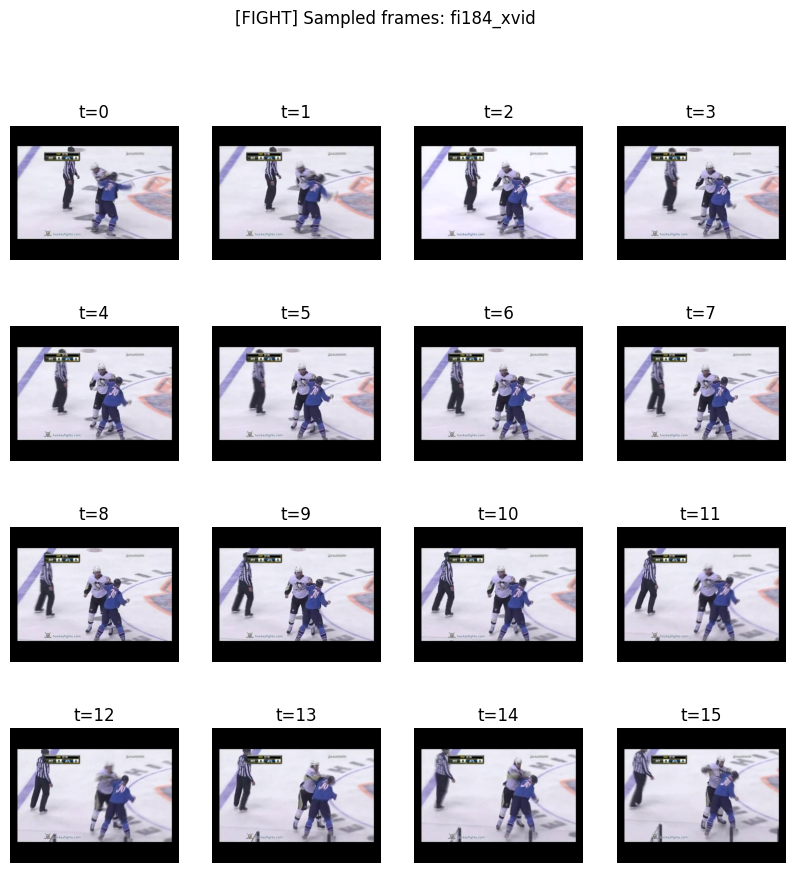

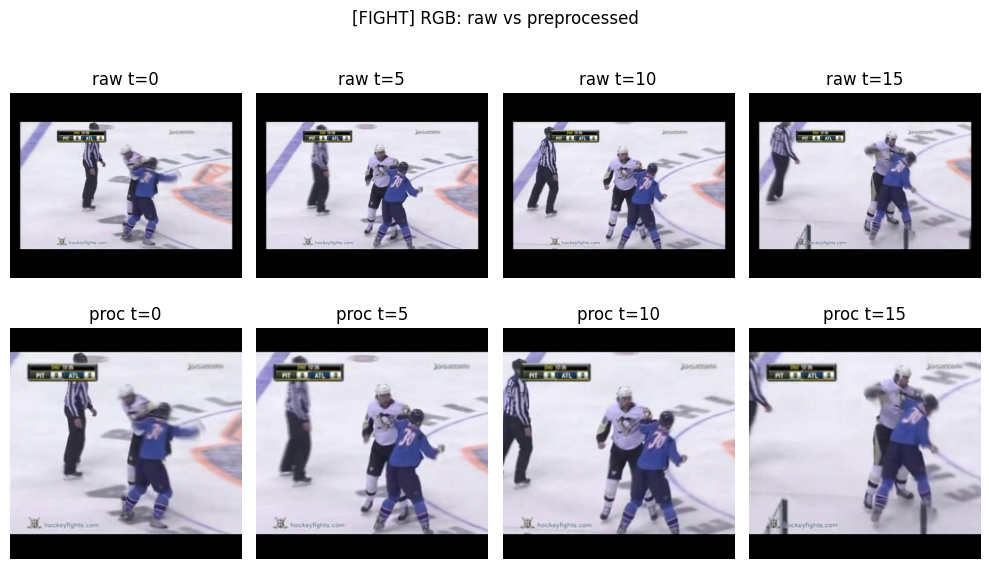

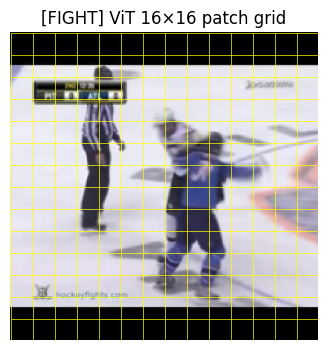

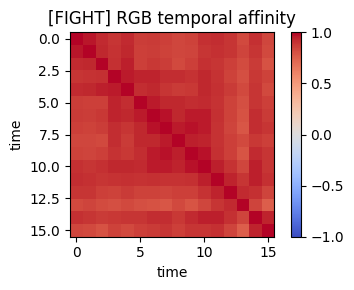

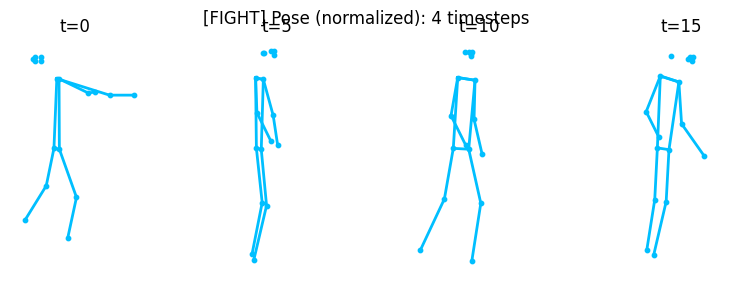

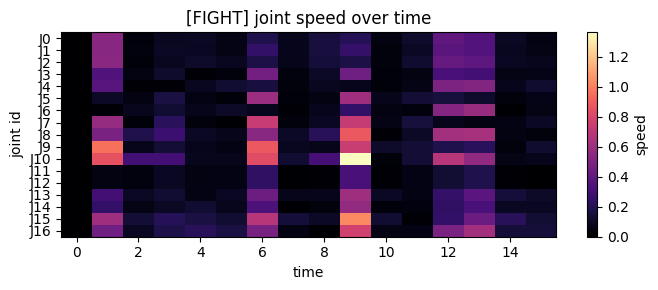

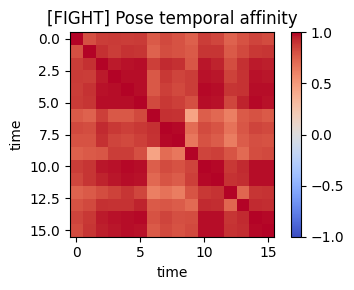

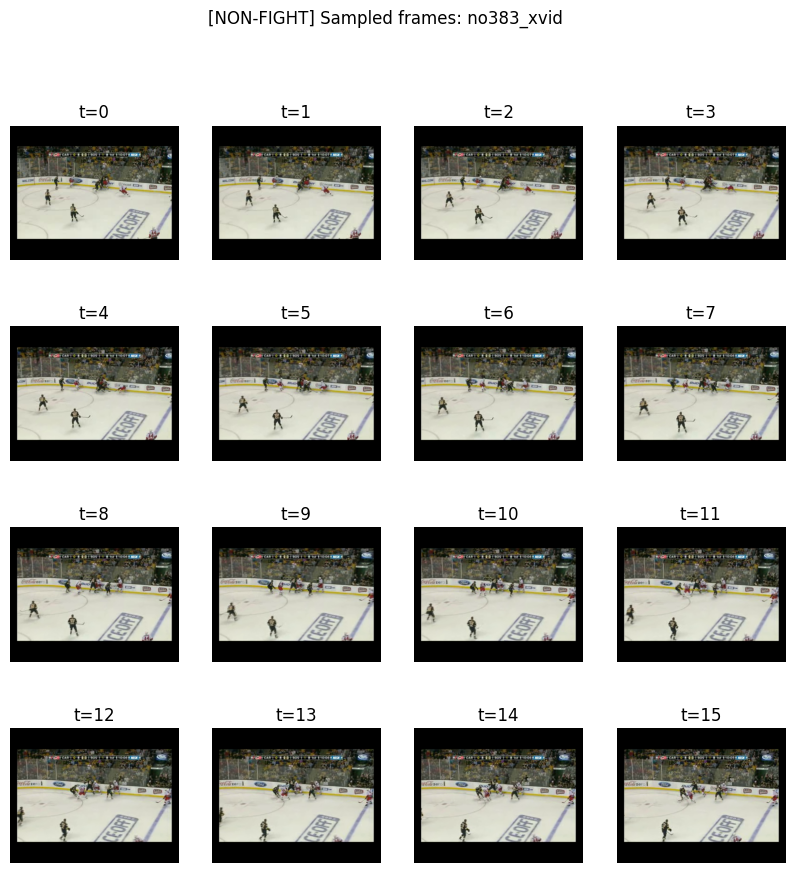

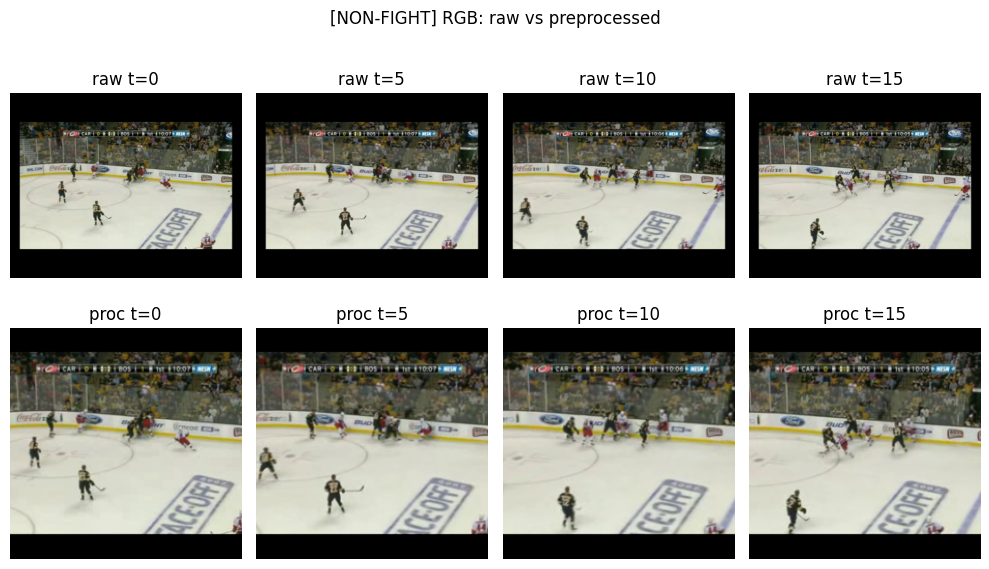

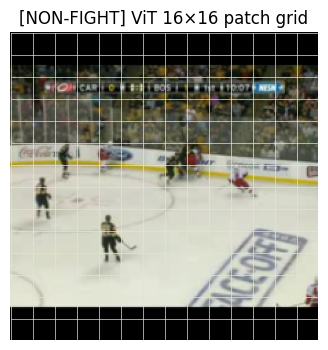

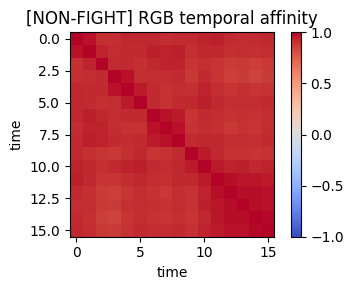

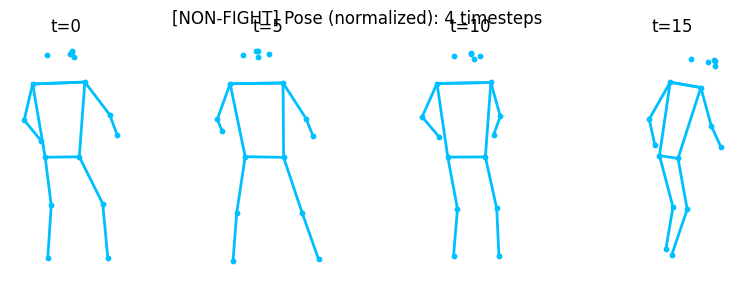

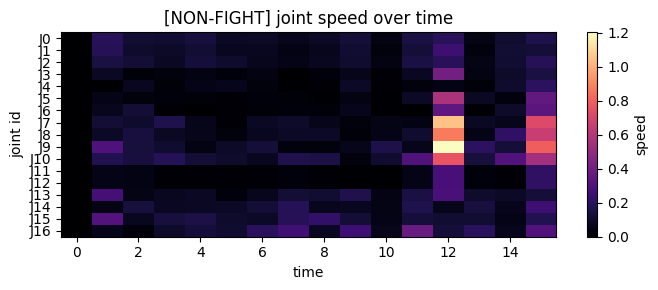

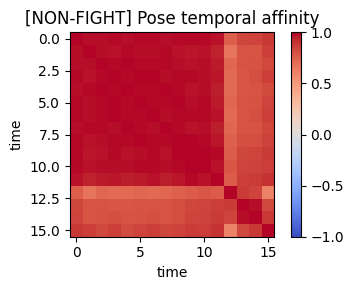

In [23]:
# ============================================
# Visualize one fighting and one non-fighting video
# (RGB pipeline + Pose pipeline, same T=16)
# ============================================
import os, cv2, random, numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torchvision
import timm

# --------- config ----------
SPLIT_TXT = os.path.join(SPLIT_DIR, "test_small.txt")   # or "train_small.txt"
T_DEMO    = 16                                          # keep equal to T_POSE for pose cache
pose_missing_ok = False                                 # set True to skip pose if npz missing
# ---------------------------

# --- helpers ---
def uniform_inds(n, T):
    if n <= 0: return np.zeros(T, dtype=int)
    return np.linspace(0, max(0, n-1), T).astype(int)

EDGES = [(5,6),(5,7),(7,9),(6,8),(8,10),(11,12),(11,13),(13,15),(12,14),(14,16),(5,11),(6,12),(5,6)]
def draw_skeleton(ax, pts, col="deepskyblue"):
    for (a,b) in EDGES:
        xa,ya = pts[a]; xb,yb = pts[b]
        ax.plot([xa,xb], [ya,yb], '-', color=col, linewidth=2)
    ax.scatter(pts[:,0], pts[:,1], s=10, c=col)

# transforms (deterministic view for demo)
mean = [0.485, 0.456, 0.406]; std = [0.229, 0.224, 0.225]
tf_eval = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean, std),
])
def denorm(t):
    t = t.clone().cpu()
    for c,(m,s) in enumerate(zip(mean, std)): t[c] = t[c]*s + m
    return (t.clamp(0,1).permute(1,2,0).numpy())

# ViT backbone (frozen) for RGB features
backbone = timm.create_model("vit_tiny_patch16_224", pretrained=True)
backbone.reset_classifier(0)
backbone.eval()

def visualize_one_video(video_path, title):
    stem = Path(video_path).stem

    # ---- sample frames ----
    cap = cv2.VideoCapture(video_path)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    inds = uniform_inds(n_frames, T_DEMO)
    raw = []
    for i in inds:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, frame = cap.read()
        if not ok: frame = np.zeros((256,256,3), dtype=np.uint8)
        raw.append(frame[:,:,::-1])   # BGR->RGB
    cap.release()

    # ---- show 4x4 contact sheet ----
    plt.figure(figsize=(10,10))
    for i, img in enumerate(raw):
        plt.subplot(4,4,i+1); plt.imshow(img); plt.axis("off"); plt.title(f"t={i}")
    plt.suptitle(f"[{title}] Sampled frames: {stem}", fontsize=12)
    plt.show()

    # ---- preprocess (RGB) ----
    proc = [tf_eval(Image.fromarray(img)) for img in raw]
    plt.figure(figsize=(10,6))
    for k, idx in enumerate([0,5,10,15]):
        plt.subplot(2,4,k+1);  plt.imshow(raw[idx]);            plt.axis("off"); plt.title(f"raw t={idx}")
        plt.subplot(2,4,k+5);  plt.imshow(denorm(proc[idx]));   plt.axis("off"); plt.title(f"proc t={idx}")
    plt.suptitle(f"[{title}] RGB: raw vs preprocessed", fontsize=12); plt.tight_layout(); plt.show()

    # ---- ViT patch grid on one processed frame ----
    img_show = denorm(proc[0])
    H, W = img_show.shape[:2]; patch=16
    plt.figure(figsize=(4,4)); plt.imshow(img_show); plt.axis("off"); plt.title(f"[{title}] ViT 16×16 patch grid")
    for r in range(0,H,patch): plt.plot([0,W-1],[r,r], color='yellow', linewidth=0.5)
    for c in range(0,W,patch): plt.plot([c,c],[0,H-1], color='yellow', linewidth=0.5)
    plt.show()

    # ---- RGB temporal affinity (cosine on ViT features) ----
    with torch.no_grad():
        X = torch.stack(proc, dim=0)        # [T,3,224,224]
        feats_list = []
        for i in range(0, T_DEMO, 8):
            feats_list.append(backbone(X[i:i+8]))   # [n, D]
        feats = torch.cat(feats_list, dim=0)        # [T, D]
        aff = F.cosine_similarity(feats[:,None,:], feats[None,:,:], dim=-1).cpu().numpy()
    plt.figure(figsize=(4,3))
    plt.imshow(aff, vmin=-1, vmax=1, cmap="coolwarm")
    plt.colorbar(); plt.title(f"[{title}] RGB temporal affinity"); plt.xlabel("time"); plt.ylabel("time")
    plt.tight_layout(); plt.show()

    # ---- Pose visualization (from cache) ----
    npz_path = os.path.join(POSE_DIR, f"{stem}_T{T_DEMO}.npz")
    if not os.path.exists(npz_path):
        print(f"[{title}] Pose file missing, skip:", npz_path)
        if not pose_missing_ok:
            print("Run cache_split_pose(...) for this split with T=16.")
        return
    data = np.load(npz_path)
    xy   = data["xy"]   # [T,17,2] root-centered, torso-scaled as you defined
    conf = data["conf"] # [T,17,1]

    # 4 stick figures
    idxs = [0,5,10,15]
    fig, axes = plt.subplots(1,4, figsize=(10,3), sharex=True, sharey=True)
    for j,i in enumerate(idxs):
        pts = xy[i].copy(); pts[:,1] *= -1  # flip Y for display
        ax = axes[j]; draw_skeleton(ax, pts, col="deepskyblue")
        ax.set_title(f"t={i}"); ax.set_aspect('equal'); ax.axis("off")
    plt.suptitle(f"[{title}] Pose (normalized): 4 timesteps", fontsize=12)
    plt.show()

    # joint speed heatmap
    vel = np.diff(xy, axis=0, prepend=xy[:1])       # [T,17,2]
    spd = np.linalg.norm(vel, axis=-1)              # [T,17]
    plt.figure(figsize=(7,3))
    plt.imshow(spd.T, aspect="auto", cmap="magma")
    plt.colorbar(label="speed"); plt.yticks(range(17), [f"J{i}" for i in range(17)])
    plt.xlabel("time"); plt.ylabel("joint id"); plt.title(f"[{title}] joint speed over time")
    plt.tight_layout(); plt.show()

    # pose temporal affinity on features [xy, vel] -> [T,68]
    feat = np.concatenate([xy, vel], axis=-1).reshape(T_DEMO, -1).astype(np.float32)
    ft   = torch.from_numpy(feat)
    sim  = F.cosine_similarity(ft[:,None,:], ft[None,:,:], dim=-1).cpu().numpy()
    plt.figure(figsize=(4,3))
    plt.imshow(sim, vmin=-1, vmax=1, cmap="coolwarm")
    plt.colorbar(); plt.title(f"[{title}] Pose temporal affinity"); plt.xlabel("time"); plt.ylabel("time")
    plt.tight_layout(); plt.show()


# -------- pick one fight + one non-fight from the chosen split --------
with open(SPLIT_TXT) as f:
    vids = [ln.strip() for ln in f if ln.strip()]
fight_vids = [v for v in vids if Path(v).name.lower().startswith("fi")]
non_vids   = [v for v in vids if Path(v).name.lower().startswith("no")]

assert fight_vids and non_vids, "Split must contain both fighting and non-fighting examples."

random.seed(42)
fight_demo = random.choice(fight_vids)
non_demo   = random.choice(non_vids)

print("Chosen fight:     ", fight_demo)
print("Chosen non-fight: ", non_demo)

# ---- run visuals for both ----
visualize_one_video(fight_demo, "FIGHT")
visualize_one_video(non_demo,  "NON-FIGHT")

# Part 6: Global configuration

In [24]:
# === Global config & paths ===
import os, random, time, math, numpy as np, torch

# Use "" for FULL dataset (train.txt / val.txt / test.txt)
# Use "_small" for the 100-video lightweight set.
SPLIT_SUFFIX = ""   # <<<<<<<<<<  FULL DATASET

# Folders used earlier in your notebook
SPLIT_DIR = "/content/splits"
POSE_DIR  = "/content/poses_npz"

# Shared temporal length
T_RGB  = 16
T_POSE = 16   # must match what you cache/load for pose

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Using splits:",
      os.path.join(SPLIT_DIR, f"train{SPLIT_SUFFIX}.txt"),
      os.path.join(SPLIT_DIR, f"val{SPLIT_SUFFIX}.txt"),
      os.path.join(SPLIT_DIR, f"test{SPLIT_SUFFIX}.txt"))

Device: cuda
Using splits: /content/splits/train.txt /content/splits/val.txt /content/splits/test.txt


# 6.2 RGB model dataset

In [25]:
# === RGB video dataset (only define if not already in scope) ===
import os, cv2
from PIL import Image
import torchvision
from torch.utils.data import Dataset, DataLoader

if 'VideoDataset' not in globals():
    class VideoDataset(Dataset):
        """
        Reads a video, uniformly samples T frames, applies transforms,
        returns tensor [T, 3, H, W] and label {0: non-fight, 1: fight}.
        """
        def __init__(self, list_file, T=16, size=224, train=True):
            with open(list_file) as f:
                self.paths = [ln.strip() for ln in f if ln.strip()]
            self.T = T
            self.size = size
            self.train = train

            # ImageNet normalization
            mean = [0.485, 0.456, 0.406]
            std  = [0.229, 0.224, 0.225]
            self.tf_train = torchvision.transforms.Compose([
                torchvision.transforms.Resize(256),
                torchvision.transforms.RandomCrop(size),
                torchvision.transforms.RandomHorizontalFlip(),
                torchvision.transforms.ToTensor(),
                torchvision.transforms.Normalize(mean, std),
            ])
            self.tf_eval = torchvision.transforms.Compose([
                torchvision.transforms.Resize(256),
                torchvision.transforms.CenterCrop(size),
                torchvision.transforms.ToTensor(),
                torchvision.transforms.Normalize(mean, std),
            ])

        def __len__(self): return len(self.paths)

        def _label(self, path):
            bn = os.path.basename(path).lower()
            return 1 if bn.startswith("fi") else 0

        def _sample_indices(self, n_frames):
            if n_frames <= 0: return np.zeros(self.T, dtype=int)
            return np.linspace(0, max(0, n_frames - 1), self.T).astype(int)

        def __getitem__(self, idx):
            path = self.paths[idx]
            y = self._label(path)

            cap = cv2.VideoCapture(path)
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            inds = self._sample_indices(total)

            imgs = []
            tf = self.tf_train if self.train else self.tf_eval
            for i in inds:
                cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
                ok, frame = cap.read()
                if not ok:
                    frame = np.zeros((256,256,3), dtype=np.uint8)
                img = Image.fromarray(frame[:, :, ::-1])  # BGR->RGB
                imgs.append(tf(img))
            cap.release()

            x = torch.stack(imgs, dim=0)  # [T,3,H,W]
            return x, torch.tensor(y).long()

# 6.3 RGB dataloader

In [26]:
# === RGB dataloaders (FULL) ===
train_list = os.path.join(SPLIT_DIR, f"train{SPLIT_SUFFIX}.txt")
val_list   = os.path.join(SPLIT_DIR, f"val{SPLIT_SUFFIX}.txt")
test_list  = os.path.join(SPLIT_DIR, f"test{SPLIT_SUFFIX}.txt")

BATCH_RGB = 4 if DEVICE == "cuda" else 2

train_ds_rgb = VideoDataset(train_list, T=T_RGB, train=True)
val_ds_rgb   = VideoDataset(val_list,   T=T_RGB, train=False)
test_ds_rgb  = VideoDataset(test_list,  T=T_RGB, train=False)

train_dl_rgb = DataLoader(train_ds_rgb, batch_size=BATCH_RGB, shuffle=True,  num_workers=2, pin_memory=True)
val_dl_rgb   = DataLoader(val_ds_rgb,   batch_size=BATCH_RGB, shuffle=False, num_workers=2, pin_memory=True)
test_dl_rgb  = DataLoader(test_ds_rgb,  batch_size=BATCH_RGB, shuffle=False, num_workers=2, pin_memory=True)

print("RGB dataset lens:", len(train_ds_rgb), len(val_ds_rgb), len(test_ds_rgb))

RGB dataset lens: 800 100 100


# 6.4 RGB model (Frame-ViT encoder + tiny temporal head)

In [27]:
# === RGB model: ViT-Tiny frame encoder + simple temporal head ===
import timm
import torch.nn as nn

class FrameViTTemporal(nn.Module):
    """
    1) Frame encoder: ViT-tiny → per-frame features [B*T, D]
    2) Temporal pooling or tiny transformer → clip feature [B, D]
    3) Linear head → logits [B, 2]
    """
    def __init__(self, num_classes=2, temporal="mean"):
        super().__init__()
        self.backbone = timm.create_model("vit_tiny_patch16_224", pretrained=True)
        self.backbone.reset_classifier(0)         # features only
        for p in self.backbone.parameters():       # freeze backbone for speed/stability
            p.requires_grad = False
        self.D = self.backbone.num_features       # ~192 for ViT-tiny

        self.temporal = temporal
        if temporal == "transformer":
            enc_layer = nn.TransformerEncoderLayer(d_model=self.D, nhead=3, batch_first=True)
            self.temporal_block = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.head = nn.Linear(self.D, num_classes)

    def forward(self, x):                 # x: [B, T, 3, H, W]
        B, T, C, H, W = x.shape
        f = self.backbone(x.view(B*T, C, H, W))    # [B*T, D]
        f = f.view(B, T, self.D)                   # [B, T, D]
        if self.temporal == "transformer":
            z = self.temporal_block(f)             # [B, T, D]
            g = z.mean(dim=1)                      # [B, D]
        else:
            g = f.mean(dim=1)                      # simple mean pooling
        return self.head(g)

model_rgb = FrameViTTemporal(num_classes=2, temporal="mean").to(DEVICE)
sum_params = sum(p.numel() for p in model_rgb.parameters() if p.requires_grad)
print("RGB trainable params:", sum_params)

RGB trainable params: 386


# 6.5 RGB training and testing

In [28]:
# === RGB training loop + evaluation ===
from sklearn.metrics import accuracy_score, f1_score
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW([p for p in model_rgb.parameters() if p.requires_grad],
                        lr=3e-4, weight_decay=5e-2)

use_amp = (DEVICE == "cuda")
scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)

def run_epoch_rgb(dl, train=True):
    model_rgb.train(train)
    losses, preds, trues = [], [], []
    for X, y in dl:
        X, y = X.to(DEVICE), y.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model_rgb(X)
            loss = criterion(logits, y)
        if train:
            optimizer.zero_grad(set_to_none=True)
            if use_amp:
                scaler.scale(loss).backward()
                nn.utils.clip_grad_norm_(model_rgb.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(model_rgb.parameters(), 1.0)
                optimizer.step()
        losses.append(loss.item())
        preds += logits.argmax(1).detach().cpu().tolist()
        trues += y.detach().cpu().tolist()
    acc = accuracy_score(trues, preds) if trues else 0.0
    f1  = f1_score(trues, preds, average="macro") if trues else 0.0
    return float(np.mean(losses)) if losses else 0.0, acc, f1

EPOCHS_RGB = 6         # adjust up/down for your runtime
BEST_F1    = -1.0
BEST_PATH_RGB = f"/content/best_rgb{SPLIT_SUFFIX}.pt"
epoch_times = []

print(f"[RGB] Training on {DEVICE} | dataset suffix '{SPLIT_SUFFIX or 'FULL'}'")
for ep in range(1, EPOCHS_RGB+1):
    t0 = time.time()
    tr_l, tr_a, tr_f = run_epoch_rgb(train_dl_rgb, True)
    va_l, va_a, va_f = run_epoch_rgb(val_dl_rgb,   False)
    dt = time.time()-t0; epoch_times.append(dt)
    print(f"Epoch {ep:02d} | train {tr_l:.3f}/{tr_a:.3f}/{tr_f:.3f}  "
          f"|| val {va_l:.3f}/{va_a:.3f}/{va_f:.3f} | {dt/60:.2f} min")
    if va_f > BEST_F1:
        BEST_F1 = va_f
        torch.save(model_rgb.state_dict(), BEST_PATH_RGB)
print("Saved best RGB model:", BEST_PATH_RGB)
print("RGB avg epoch time:", np.mean(epoch_times)/60, "min")

# Test
model_rgb.load_state_dict(torch.load(BEST_PATH_RGB, map_location=DEVICE))
model_rgb.eval()
_, te_acc, te_f1 = run_epoch_rgb(test_dl_rgb, train=False)
print(f"[RGB TEST {SPLIT_SUFFIX or 'FULL'}] acc={te_acc:.3f} | macro-F1={te_f1:.3f}")

[RGB] Training on cuda | dataset suffix 'FULL'


/tmp/ipykernel_5495/691679132.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_5495/691679132.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_5495/691679132.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 01 | train 0.490/0.802/0.802  || val 0.316/0.910/0.910 | 2.24 min


/tmp/ipykernel_5495/691679132.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_5495/691679132.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 02 | train 0.283/0.920/0.920  || val 0.344/0.930/0.930 | 2.17 min


...

Epoch 05 | train 0.378/0.935/0.935  || val 0.484/0.930/0.930 | 2.13 min


/tmp/ipykernel_5495/691679132.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_5495/691679132.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 06 | train 0.419/0.939/0.939  || val 0.515/0.930/0.930 | 2.14 min
Saved best RGB model: /content/best_rgb.pt
RGB avg epoch time: 2.1520055174827575 min


/tmp/ipykernel_5495/691679132.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[RGB TEST FULL] acc=0.940 | macro-F1=0.940


# 7.1 POSE model cache

In [29]:
# === Pose cache for FULL splits (safe to re-run; skips existing files) ===
from pathlib import Path
import os

# ---------------------------------------------------
# Define base cache directory if not already present
CACHE_DIR = "./cache"     # or use your actual cache root path
os.makedirs(CACHE_DIR, exist_ok=True)
# ---------------------------------------------------

# --------------- KEY SWITCHES ---------------
SPLIT_SUFFIX = ""          # << force FULL dataset: train.txt / val.txt / test.txt
T_POSE = 16
POSE_DIR = os.path.join(CACHE_DIR, f"pose_full_T{T_POSE}")   # keep a separate cache folder
os.makedirs(POSE_DIR, exist_ok=True)
# --------------------------------------------

def _maybe_cache_full_pose():
    if 'extract_video_kps' not in globals():
        print("extract_video_kps(...) not found; assuming poses are already cached.")
        return

    def cache_split_pose(list_path, T=16):
        from tqdm import tqdm
        with open(list_path) as f:
            vids = [ln.strip() for ln in f if ln.strip()]
        print(f"\nProcessing split: {Path(list_path).name} | total videos = {len(vids)}")
        for vp in tqdm(vids, ncols=80, desc=f"Pose cache {Path(list_path).name}"):
            stem = Path(vp).stem
            out  = os.path.join(POSE_DIR, f"{stem}_T{T}.npz")
            if os.path.exists(out):
                continue
            xy, conf = extract_video_kps(vp, T=T)  # returns [T,17,2], [T,17]
            np.savez_compressed(out, xy=xy, conf=conf)

    for nm in ["train", "val", "test"]:
        cache_split_pose(os.path.join(SPLIT_DIR, f"{nm}{SPLIT_SUFFIX}.txt"), T=T_POSE)

_maybe_cache_full_pose()


Processing split: train.txt | total videos = 800


Pose cache train.txt: 100%|███████████████████| 800/800 [03:19<00:00,  4.01it/s]



Processing split: val.txt | total videos = 100


Pose cache val.txt: 100%|█████████████████████| 100/100 [00:24<00:00,  4.03it/s]



Processing split: test.txt | total videos = 100


Pose cache test.txt: 100%|████████████████████| 100/100 [00:24<00:00,  4.03it/s]


# 7.2 POSE model dataset

In [30]:
# === 8.2 POSE dataset & loaders (FULL set: ≈800/100/100) ===
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np, torch, os

SPLIT_SUFFIX = ""          # make sure it's the full set
T_POSE = 16                # keep consistent with cache
POSE_DIR = POSE_DIR        # from 8.1 (pose_full_T16)

class PoseDataset(Dataset):
    def __init__(self, list_file, pose_dir, T=16, use_speed=True):
        with open(list_file) as f:
            self.videos = [ln.strip() for ln in f if ln.strip()]
        self.pose_dir = pose_dir
        self.T = T
        self.use_speed = use_speed

    def __len__(self):
        return len(self.videos)

    def _label(self, path):
        # works for names like fi_xxx.avi / no_xxx.avi
        bn = os.path.basename(path).lower()
        return 1 if bn.startswith("fi") else 0

    def __getitem__(self, idx):
        vp = self.videos[idx]
        stem = Path(vp).stem
        npz_path = os.path.join(self.pose_dir, f"{stem}_T{self.T}.npz")
        data = np.load(npz_path, allow_pickle=False, mmap_mode="r")
        xy   = data["xy"]                     # [T,17,2]
        # conf = data["conf"]                 # [T,17]  (available if you want it)

        if self.use_speed:
            vel  = np.diff(xy, axis=0, prepend=xy[:1])   # [T,17,2]
            feat = np.concatenate([xy, vel], axis=-1)    # [T,17,4]
            feat = feat.reshape(self.T, -1)              # [T,68]
        else:
            feat = xy.reshape(self.T, -1)                # [T,34]

        x = torch.from_numpy(feat).float()               # [T, D]
        y = torch.tensor(self._label(vp)).long()
        return x, y

# --- point to FULL split files ---
train_list = os.path.join(SPLIT_DIR, f"train{SPLIT_SUFFIX}.txt")
val_list   = os.path.join(SPLIT_DIR, f"val{SPLIT_SUFFIX}.txt")
test_list  = os.path.join(SPLIT_DIR, f"test{SPLIT_SUFFIX}.txt")

pose_train_ds = PoseDataset(train_list, POSE_DIR, T=T_POSE, use_speed=True)
pose_val_ds   = PoseDataset(val_list,   POSE_DIR, T=T_POSE, use_speed=True)
pose_test_ds  = PoseDataset(test_list,  POSE_DIR, T=T_POSE, use_speed=True)

# --- loaders (CPU-friendly) ---
pose_train_loader = DataLoader(pose_train_ds, batch_size=64, shuffle=True,  num_workers=0)
pose_val_loader   = DataLoader(pose_val_ds,   batch_size=64, shuffle=False, num_workers=0)
pose_test_loader  = DataLoader(pose_test_ds,  batch_size=64, shuffle=False, num_workers=0)

# quick sanity print
print("FULL Pose splits ->",
      f"train:{len(pose_train_ds)} val:{len(pose_val_ds)} test:{len(pose_test_ds)}")

FULL Pose splits -> train:800 val:100 test:100


# 7.3 POSE dataloader

In [31]:
# === Pose dataloaders (FULL) ===
train_list = os.path.join(SPLIT_DIR, f"train{SPLIT_SUFFIX}.txt")
val_list   = os.path.join(SPLIT_DIR, f"val{SPLIT_SUFFIX}.txt")
test_list  = os.path.join(SPLIT_DIR, f"test{SPLIT_SUFFIX}.txt")

BATCH_POSE = 64  # pose features are tiny
pose_train = PoseDataset(train_list, POSE_DIR, T=T_POSE, use_speed=True)
pose_val   = PoseDataset(val_list,   POSE_DIR, T=T_POSE, use_speed=True)
pose_test  = PoseDataset(test_list,  POSE_DIR, T=T_POSE, use_speed=True)

train_dl_pose = DataLoader(pose_train, batch_size=BATCH_POSE, shuffle=True,  num_workers=0)
val_dl_pose   = DataLoader(pose_val,   batch_size=BATCH_POSE, shuffle=False, num_workers=0)
test_dl_pose  = DataLoader(pose_test,  batch_size=BATCH_POSE, shuffle=False, num_workers=0)

print("Pose dataset lens:", len(pose_train), len(pose_val), len(pose_test))
print("Sample pose shape [T,D]:", pose_train[0][0].shape)

Pose dataset lens: 800 100 100
Sample pose shape [T,D]: torch.Size([16, 68])


#7.4 POSE tmeporal transformer

In [32]:
# === Pose model (Temporal transformer) ===
import torch.nn as nn
import torch.nn.functional as F

class TemporalPose(nn.Module):
    def __init__(self, d_in, d_model=256, nhead=4, layers=3, num_classes=2, max_T=128):
        super().__init__()
        self.proj = nn.Linear(d_in, d_model)
        self.pos  = nn.Parameter(torch.zeros(1, max_T, d_model))
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.enc  = nn.TransformerEncoder(enc, num_layers=layers)
        self.head = nn.Linear(d_model, num_classes)
    def forward(self, x):                   # x: [B, T, d_in]
        z = self.proj(x)                    # [B, T, d_model]
        B, T, _ = z.shape
        z = z + self.pos[:, :T, :]
        z = self.enc(z)                     # [B, T, d_model]
        g = z.mean(dim=1)                   # [B, d_model]
        return self.head(g)

# infer d_in and dry forward
xb, yb = next(iter(train_dl_pose))
D_IN = xb.shape[-1]
model_pose = TemporalPose(d_in=D_IN, d_model=256, nhead=4, layers=3, num_classes=2).to(DEVICE)
with torch.no_grad():
    _ = model_pose(xb.to(DEVICE))
print("Pose proj in_features:", model_pose.proj.in_features, "| dry forward OK")

Pose proj in_features: 68 | dry forward OK


# 7.5 POSE training and testing

In [33]:
# === Pose training loop + evaluation ===
criterion_pose = nn.CrossEntropyLoss()
optim_pose = torch.optim.AdamW(model_pose.parameters(), lr=3e-4, weight_decay=5e-2)

def run_epoch_pose(dl, train=True):
    model_pose.train(train)
    losses, preds, trues = [], [], []
    with torch.set_grad_enabled(train):
        for X, y in dl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model_pose(X)
            loss = criterion_pose(logits, y)
            if train:
                optim_pose.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model_pose.parameters(), 1.0)
                optim_pose.step()
            losses.append(loss.item())
            preds += logits.argmax(1).detach().cpu().tolist()
            trues += y.detach().cpu().tolist()
    acc = accuracy_score(trues, preds) if trues else 0.0
    f1  = f1_score(trues, preds, average="macro") if trues else 0.0
    return float(np.mean(losses)) if losses else 0.0, acc, f1

EPOCHS_POSE = 12
BEST_F1 = -1.0
BEST_PATH_POSE = f"/content/best_pose{SPLIT_SUFFIX}.pt"
epoch_times = []

print(f"[Pose] Training on {DEVICE} | dataset suffix '{SPLIT_SUFFIX or 'FULL'}'")
for ep in range(1, EPOCHS_POSE+1):
    t0 = time.time()
    tr_l, tr_a, tr_f = run_epoch_pose(train_dl_pose, True)
    va_l, va_a, va_f = run_epoch_pose(val_dl_pose,   False)
    dt = time.time()-t0; epoch_times.append(dt)
    print(f"Epoch {ep:02d} | train {tr_l:.3f}/{tr_a:.3f}/{tr_f:.3f}  "
          f"|| val {va_l:.3f}/{va_a:.3f}/{va_f:.3f} | {dt/60:.2f} min")
    if va_f > BEST_F1:
        BEST_F1 = va_f
        torch.save(model_pose.state_dict(), BEST_PATH_POSE)

print("Saved best Pose model:", BEST_PATH_POSE)
print("Pose avg epoch time:", np.mean(epoch_times)/60, "min")

# Test
model_pose.load_state_dict(torch.load(BEST_PATH_POSE, map_location=DEVICE))
model_pose.eval()
_, te_acc, te_f1 = run_epoch_pose(test_dl_pose, train=False)
print(f"[POSE TEST {SPLIT_SUFFIX or 'FULL'}] acc={te_acc:.3f} | macro-F1={te_f1:.3f}")

[Pose] Training on cuda | dataset suffix 'FULL'
Epoch 01 | train 0.948/0.524/0.523  || val 0.585/0.760/0.758 | 0.01 min
Epoch 02 | train 0.512/0.759/0.759  || val 0.317/0.900/0.900 | 0.01 min
Epoch 03 | train 0.425/0.818/0.817  || val 0.372/0.820/0.817 | 0.01 min
Epoch 04 | train 0.352/0.839/0.839  || val 0.277/0.860/0.859 | 0.01 min
Epoch 05 | train 0.307/0.874/0.874  || val 0.295/0.900/0.900 | 0.01 min
Epoch 06 | train 0.295/0.875/0.875  || val 0.290/0.880/0.880 | 0.01 min
Epoch 07 | train 0.224/0.906/0.906  || val 0.340/0.870/0.869 | 0.01 min
Epoch 08 | train 0.199/0.921/0.921  || val 0.291/0.910/0.910 | 0.01 min
Epoch 09 | train 0.200/0.919/0.919  || val 0.448/0.830/0.827 | 0.01 min
Epoch 10 | train 0.162/0.936/0.936  || val 0.411/0.870/0.868 | 0.01 min
Epoch 11 | train 0.128/0.944/0.944  || val 0.295/0.920/0.920 | 0.01 min
Epoch 12 | train 0.124/0.956/0.956  || val 0.336/0.870/0.870 | 0.01 min
Saved best Pose model: /content/best_pose.pt
Pose avg epoch time: 0.010614048772388035 m

# 8.1 Pose model variations

In [34]:
import os, glob, time, random
from pathlib import Path
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

SPLIT_SUFFIX = ""
T_POSE = 16
BATCH_POSE = 64
LR = 3e-4
WD = 5e-2
EPOCHS = 12
PATIENCE = 4
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SPLIT_DIR = "/content/splits"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def _infer_data_root():
    cands = ["/root/.cache/kagglehub/datasets/yassershrief/hockey-fight-vidoes/versions/1/data", "/content/data", "/content"]
    for c in cands:
        if c and os.path.isdir(c) and glob.glob(os.path.join(c, "*.avi")):
            return c
    raise FileNotFoundError("DATA_ROOT not defined and could not be inferred.")

if 'DATA_ROOT' not in globals() or not (os.path.isdir(DATA_ROOT) and glob.glob(os.path.join(DATA_ROOT, "*.avi"))):
    DATA_ROOT = _infer_data_root()

def _label(p):
    bn = os.path.basename(p).lower()
    if bn.startswith("fi"): return 1
    if bn.startswith("no"): return 0
    raise ValueError(f"Unknown prefix: {bn}")

def ensure_base_splits(split_dir, data_root, seed=42):
    Path(split_dir).mkdir(parents=True, exist_ok=True)
    base = {nm: os.path.join(split_dir, f"{nm}.txt") for nm in ["train","val","test"]}
    if all(os.path.exists(p) for p in base.values()): return
    avi = sorted(glob.glob(os.path.join(data_root, "*.avi")))
    from sklearn.model_selection import train_test_split
    X_train, X_tmp, y_train, y_tmp = train_test_split(avi, [_label(p) for p in avi], test_size=0.2, stratify=[_label(p) for p in avi], random_state=seed)
    X_val, X_test, _, _ = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=seed)
    def dump(lst, name): open(os.path.join(split_dir, name), "w").write("\n".join(lst))
    dump(X_train, "train.txt"); dump(X_val, "val.txt"); dump(X_test, "test.txt")

ensure_base_splits(SPLIT_DIR, DATA_ROOT, seed=SEED)

def _motion_kernel(ksize):
    k = np.zeros((ksize, ksize), dtype=np.float32)
    k[ksize//2, :] = 1.0
    return k / ksize

def apply_aug_bgr(img, kind, strength):
    s = float(np.clip(strength, 0.0, 1.0))
    if kind == 'gaussian_blur':
        k = int(3 + s * 18); k = k + 1 if k % 2 == 0 else k
        return cv2.GaussianBlur(img, (k, k), 0)
    if kind == 'motion_blur':
        k = max(3, int(3 + s * 20)); k = k + 1 if k % 2 == 0 else k
        return cv2.filter2D(img, -1, _motion_kernel(k))
    if kind == 'brightness_contrast':
        alpha = 0.6 + s * 1.0; beta = int((s * 2 - 1) * 64)
        return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    if kind == 'grayscale':
        g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return cv2.cvtColor(g, cv2.COLOR_GRAY2BGR)
    if kind == 'canny_edges':
        g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        lo = int(30 + s * 70); hi = int(90 + s * 120)
        edges = cv2.Canny(g, lo, hi)
        return cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
    if kind == 'jpeg_compress':
        q = max(5, int(100 - s * 80))
        enc = cv2.imencode('.jpg', img, [int(cv2.IMWRITE_JPEG_QUALITY), q])[1]
        return cv2.imdecode(enc, cv2.IMREAD_COLOR)
    if kind == 'gaussian_noise':
        std = s * 25.0
        noise = np.random.normal(0, std, img.shape).astype(np.float32)
        return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return img

def _uniform_inds(n, T):
    if n <= 0: return np.zeros(T, dtype=int)
    return np.linspace(0, max(0, n - 1), T).astype(int)

try:
    pose_model
    pose_device
except NameError:
    from ultralytics import YOLO
    pose_model  = YOLO("yolov8n-pose.pt")
    pose_device = "cuda" if torch.cuda.is_available() else "cpu"
    pose_model.to(pose_device)

def extract_video_kps_aug(video_path, T=16, augment='gaussian_blur', strength=0.6):
    cap = cv2.VideoCapture(video_path)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = _uniform_inds(n, T)
    seq = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, frame = cap.read()
        if not ok:
            seq.append(np.zeros((17, 3), dtype=np.float32))
            continue
        frame_aug = apply_aug_bgr(frame, augment, strength)
        rgb = cv2.cvtColor(frame_aug, cv2.COLOR_BGR2RGB)
        res = pose_model.predict(source=rgb, verbose=False, imgsz=640, device=pose_device)
        if len(res) == 0 or len(res[0].keypoints) == 0:
            seq.append(np.zeros((17, 3), dtype=np.float32))
            continue
        kps = res[0].keypoints.xy[0].cpu().numpy()
        sc  = res[0].keypoints.conf[0].cpu().numpy()
        K = min(17, kps.shape[0])
        arr = np.zeros((17, 3), dtype=np.float32)
        arr[:K, :2] = kps[:K]
        arr[:K, 2]  = sc[:K]
        seq.append(arr)
    cap.release()
    seq = np.stack(seq, axis=0)
    xy = seq[..., :2]; conf = seq[..., 2:3]
    root = (xy[:, 11] + xy[:, 12]) / 2.0
    xy = xy - root[:, None, :]
    torso = np.linalg.norm((xy[:, 5] + xy[:, 6]) / 2.0 - (xy[:, 11] + xy[:, 12]) / 2.0, axis=1) + 1e-6
    xy = xy / torso[:, None, None]
    return xy.astype(np.float32), conf.astype(np.float32)

def cache_split_pose_aug(list_path, pose_dir_aug, T=16, augment='gaussian_blur', strength=0.6):
    with open(list_path) as f:
        vids = [ln.strip() for ln in f if ln.strip()]
    Path(pose_dir_aug).mkdir(parents=True, exist_ok=True)
    for vp in tqdm(vids, ncols=80, desc=f"Pose cache {Path(list_path).name}"):
        stem = Path(vp).stem
        out  = os.path.join(pose_dir_aug, f"{stem}_T{T}.npz")
        if os.path.exists(out): continue
        xy, conf = extract_video_kps_aug(vp, T=T, augment=augment, strength=strength)
        np.savez_compressed(out, xy=xy, conf=conf)

class PoseDatasetAug(Dataset):
    def __init__(self, list_file, pose_dir, T=T_POSE, use_speed=True):
        with open(list_file) as f:
            self.videos = [ln.strip() for ln in f if ln.strip()]
        self.pose_dir = pose_dir; self.T = T; self.use_speed = use_speed
    def __len__(self): return len(self.videos)
    def _label(self, path): return 1 if Path(path).name.lower().startswith("fi") else 0
    def __getitem__(self, idx):
        vp = self.videos[idx]; stem = Path(vp).stem
        npz_path = os.path.join(self.pose_dir, f"{stem}_T{self.T}.npz")
        data = np.load(npz_path, allow_pickle=False, mmap_mode="r")
        xy = data["xy"]
        if self.use_speed:
            vel = np.diff(xy, axis=0, prepend=xy[:1])
            feat = np.concatenate([xy, vel], axis=-1).reshape(self.T, -1)
        else:
            feat = xy.reshape(self.T, -1)
        x = torch.from_numpy(feat).float(); y = torch.tensor(self._label(vp)).long()
        return x, y

class TemporalPose(nn.Module):
    def __init__(self, d_in, d_model=256, nhead=4, layers=3, num_classes=2, max_T=128):
        super().__init__()
        self.proj = nn.Linear(d_in, d_model)
        self.pos  = nn.Parameter(torch.zeros(1, max_T, d_model))
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.enc  = nn.TransformerEncoder(enc, num_layers=layers)
        self.head = nn.Linear(d_model, num_classes)
    def forward(self, x):
        z = self.proj(x)
        B, T, _ = z.shape
        z = z + self.pos[:, :T, :]
        z = self.enc(z)
        g = z.mean(dim=1)
        return self.head(g)

def run_epoch(dl, model, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    losses, preds, trues = [], [], []
    with torch.set_grad_enabled(train):
        for X, y in dl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            logits = model(X)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            losses.append(loss.item())
            preds += logits.argmax(1).detach().cpu().tolist()
            trues += y.detach().cpu().tolist()
    acc = accuracy_score(trues, preds) if trues else 0.0
    f1  = f1_score(trues, preds, average="macro") if trues else 0.0
    return float(np.mean(losses)) if losses else 0.0, acc, f1

def train_and_eval_for_aug(augment='gaussian_blur', strength=0.6):
    suffix_name = (SPLIT_SUFFIX or "full")
    pose_dir_aug = f"/content/poses_npz_aug_{augment}_{suffix_name}_T{T_POSE}"
    Path(pose_dir_aug).mkdir(parents=True, exist_ok=True)
    if SPLIT_SUFFIX == "_small":
        lists = [os.path.join(SPLIT_DIR, nm) for nm in ["train_small.txt","val_small.txt","test_small.txt"]]
    else:
        lists = [os.path.join(SPLIT_DIR, nm) for nm in ["train.txt","val.txt","test.txt"]]
    for p in lists: assert os.path.exists(p)
    train_list, val_list, test_list = lists
    for lst in [train_list, val_list, test_list]:
        cache_split_pose_aug(lst, pose_dir_aug, T=T_POSE, augment=augment, strength=strength)
    ds_tr = PoseDatasetAug(train_list, pose_dir_aug, T=T_POSE, use_speed=True)
    ds_va = PoseDatasetAug(val_list,   pose_dir_aug, T=T_POSE, use_speed=True)
    ds_te = PoseDatasetAug(test_list,  pose_dir_aug, T=T_POSE, use_speed=True)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_POSE, shuffle=True,  num_workers=0)
    dl_va = DataLoader(ds_va, batch_size=BATCH_POSE, shuffle=False, num_workers=0)
    dl_te = DataLoader(ds_te, batch_size=BATCH_POSE, shuffle=False, num_workers=0)
    xb, yb = next(iter(dl_tr))
    d_in = xb.shape[-1]
    model = TemporalPose(d_in=d_in, d_model=256, nhead=4, layers=3, num_classes=2).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    best_f1, no_imp = -1.0, 0
    best_path = f"/content/best_pose_{augment}_{suffix_name}.pt"
    epoch_times = []
    for ep in range(1, EPOCHS+1):
        t0 = time.time()
        tr_l, tr_a, tr_f = run_epoch(dl_tr, model, criterion, optimizer)
        va_l, va_a, va_f = run_epoch(dl_va, model, criterion, optimizer=None)
        dt = time.time() - t0; epoch_times.append(dt)
        if va_f > best_f1:
            best_f1 = va_f
            torch.save(model.state_dict(), best_path)
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= PATIENCE: break
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    model.eval()
    _, te_acc, te_f1 = run_epoch(dl_te, model, criterion, optimizer=None)
    return {"augment": augment, "acc": float(te_acc), "f1": float(te_f1), "best_ckpt": best_path, "avg_epoch_min": float(np.mean(epoch_times)/60.0) if epoch_times else 0.0}

variations = [("gaussian_blur", 0.6), ("canny_edges", 0.6), ("grayscale", 0.6)]
results = []
for aug, st in variations:
    out = train_and_eval_for_aug(augment=aug, strength=st)
    results.append(out)
print("\n==== SUMMARY (POSE) ====")
print(f"{'Augment':<16} {'Acc':>6} {'F1':>6} {'Avg Epoch (min)':>16}")
for r in results:
    print(f"{r['augment']:<16} {r['acc']:>6.3f} {r['f1']:>6.3f} {r['avg_epoch_min']:>16.2f}")

Pose cache test.txt: 100%|████████████████████| 100/100 [00:25<00:00,  3.94it/s]



==== SUMMARY (POSE) ====
Augment             Acc     F1  Avg Epoch (min)
gaussian_blur     0.820  0.820             0.01
canny_edges       0.810  0.810             0.01
grayscale         0.870  0.870             0.01
